# belief eye neural analysis


## imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:

import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
# misc
import pickle
from collections import defaultdict
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# run this once per notebook session  —  ideally in the first cell
from IPython import get_ipython

def notify_exc(shell, etype, evalue, tb, tb_offset=None):
    # 1. push notification
    summary = f"{etype.__name__}: {evalue}"
    notify(msg=summary, title="Python Error")

    # 2. let IPython show its normal traceback
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)
    return None            # ← must be None or a list of strings

get_ipython().set_custom_exc((Exception,), notify_exc)


## load data

## load standard data


In [4]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [5]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [6]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [7]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [8]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

In [9]:
timedf.columns                                                           

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

## load iti data

In [10]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [11]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# plots

Using 5000 of 400117 samples

── Standard Moving Average ──
 window= 2 |r| belief/state/eye = 0.381/0.530/0.613
 window= 4 |r| belief/state/eye = 0.250/0.431/0.520
 window= 6 |r| belief/state/eye = 0.144/0.354/0.451
 window= 8 |r| belief/state/eye = 0.106/0.310/0.399
 window=10 |r| belief/state/eye = 0.104/0.289/0.371
 window=12 |r| belief/state/eye = 0.084/0.267/0.354
 window=16 |r| belief/state/eye = 0.082/0.239/0.323
 window=20 |r| belief/state/eye = 0.064/0.214/0.278

── Pure Lag ──
 lag k= 1 |r| belief/state/eye = 0.194/0.306/0.401
 lag k= 2 |r| belief/state/eye = 0.076/0.126/0.231
 lag k= 3 |r| belief/state/eye = 0.011/0.014/0.097
 lag k= 4 |r| belief/state/eye = 0.033/0.022/0.073
 lag k= 5 |r| belief/state/eye = 0.041/0.040/0.055
 lag k= 6 |r| belief/state/eye = 0.021/0.036/0.053
 lag k= 8 |r| belief/state/eye = 0.012/0.036/0.037
 lag k=10 |r| belief/state/eye = 0.019/0.008/0.039
 lag k=12 |r| belief/state/eye = 0.035/0.016/0.018


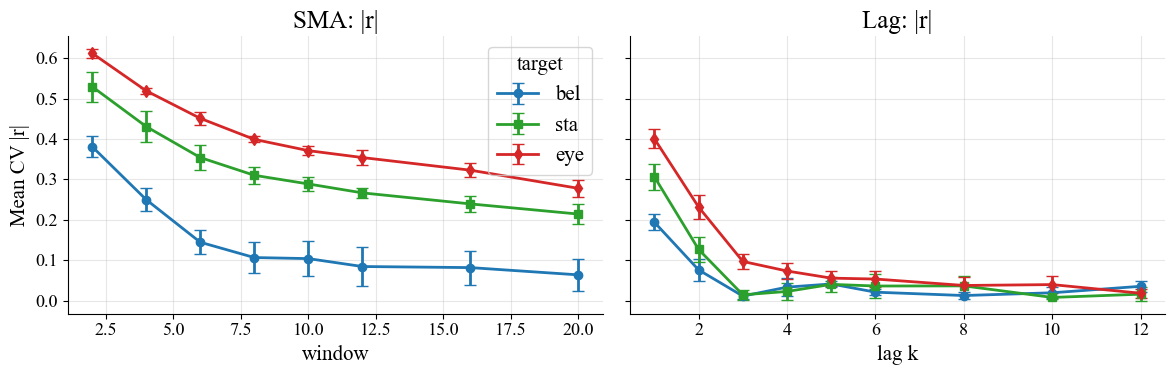

In [16]:
def analyze_sma_lag_decoding(timedf,       # … same signature as before …
                             state_col="state", eye_col="eye",
                             window_sizes=(2,4,6,8,10,12,16,20),
                             lags=(1,2,3,4,5,6,8,10,12),
                             n_samples=5_000, n_folds=5):

    # ---------- pull arrays ----------
    belief     = timedf["belief"].to_numpy()
    state      = timedf[state_col].to_numpy()
    eye        = timedf[eye_col].to_numpy()
    neural_raw = np.vstack(timedf["PPC"])
    unc_var    = timedf["uncertainty"].apply(lambda m: m[0,0]).to_numpy()
    mean_unc   = np.mean(unc_var)
    n_neurons, total_T = neural_raw.shape[1], belief.size

    # ---------- optional subsample ----------
    if n_samples < total_T:
        idx = np.sort(np.random.default_rng(42).choice(total_T, n_samples, replace=False))
        belief, state, eye = belief[idx], state[idx], eye[idx]
        neural_raw, unc_var = neural_raw[idx], unc_var[idx]
        print(f"Using {n_samples} of {total_T} samples")
    else:
        print(f"Using all {total_T} samples")

    # ---------- helper to score a design matrix ----------
    def evaluate(X, y_b, y_s, y_e, var, mean_unc, kf):
        ll_b, ll_s, ll_e = [], [], []
        r_b,  r_s,  r_e  = [], [], []
        for tr, te in kf.split(y_b):
            Xtr, Xte = X[tr], X[te]

            # belief (weights = 1/σ²)
            mdl_b = LinearRegression().fit(Xtr, y_b[tr], sample_weight=1/var[tr])
            pred_b = mdl_b.predict(Xte)
            ll_b.append(-0.5*np.sum(np.log(2*np.pi*var[te]) + (y_b[te]-pred_b)**2/var[te]))
            r_b.append(abs(pearsonr(y_b[te], pred_b)[0]))

            # state
            mdl_s = LinearRegression().fit(Xtr, y_s[tr]);  pred_s = mdl_s.predict(Xte)
            ll_s.append(-0.5*np.sum(np.log(2*np.pi*mean_unc) + (y_s[te]-pred_s)**2/mean_unc))
            r_s.append(abs(pearsonr(y_s[te], pred_s)[0]))

            # eye
            mdl_e = LinearRegression().fit(Xtr, y_e[tr]);  pred_e = mdl_e.predict(Xte)
            ll_e.append(-0.5*np.sum(np.log(2*np.pi*mean_unc) + (y_e[te]-pred_e)**2/mean_unc))
            r_e.append(abs(pearsonr(y_e[te], pred_e)[0]))

        return dict(bel=dict(mean_ll=np.mean(ll_b), std_ll=np.std(ll_b),
                             mean_r=np.mean(r_b),  std_r=np.std(r_b)),
                    sta=dict(mean_ll=np.mean(ll_s), std_ll=np.std(ll_s),
                             mean_r=np.mean(r_s),  std_r=np.std(r_s)),
                    eye=dict(mean_ll=np.mean(ll_e), std_ll=np.std(ll_e),
                             mean_r=np.mean(r_e),  std_r=np.std(r_e)))

    kf      = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {"SMA": {}, "Lag": {}}

    # ---------- A) SMA sweep ----------
    print("\n── Standard Moving Average ──")
    for w in window_sizes:
        smoothed = np.empty_like(neural_raw, float)
        for j in range(n_neurons):
            x       = neural_raw[:, j]
            cumsum  = np.cumsum(np.insert(x, 0, 0.0))
            if w == 1:
                sma = x
            else:
                tail = (cumsum[w:] - cumsum[:-w]) / w                 # length T‑w+1
                head = cumsum[1:w] / np.arange(1, w)                 # length w‑1
                sma  = np.concatenate((head, tail))                   # length T
            smoothed[:, j] = sma
        results["SMA"][w] = evaluate(smoothed, belief, state, eye, unc_var, mean_unc, kf)
        m = results["SMA"][w]
        print(f" window={w:2d} |r| belief/state/eye = "
              f"{m['bel']['mean_r']:.3f}/{m['sta']['mean_r']:.3f}/{m['eye']['mean_r']:.3f}")

    # ---------- B) Lag sweep ----------
    print("\n── Pure Lag ──")
    for k in lags:
        if k >= len(belief) - 10:   # leave some samples
            continue
        X_lag   = neural_raw[:-k]
        res     = evaluate(X_lag,
                           belief[k:], state[k:], eye[k:],
                           unc_var[k:], mean_unc, kf)
        results["Lag"][k] = res
        print(f" lag k={k:2d} |r| belief/state/eye = "
              f"{res['bel']['mean_r']:.3f}/{res['sta']['mean_r']:.3f}/{res['eye']['mean_r']:.3f}")

    # ---------- quick sanity plot (|r| only) ----------
    fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
    for ax, (meth, params) in zip(axes, results.items()):
        ps = sorted(params)
        for tgt, clr, mkr in zip(("bel","sta","eye"),
                                 ("tab:blue","tab:green","tab:red"),
                                 ("o","s","d")):
            ax.errorbar(ps,
                        [results[meth][p][tgt]['mean_r'] for p in ps],
                        yerr=[results[meth][p][tgt]['std_r']  for p in ps],
                        fmt=mkr+"-", capsize=4, color=clr, label=tgt)
        ax.set(title=f"{meth}: |r|", xlabel="window" if meth=="SMA" else "lag k")
        ax.grid(alpha=.3)
    axes[0].set_ylabel("Mean CV |r|")
    axes[0].legend(title="target")
    plt.tight_layout(); plt.show()

    return results


results_sma_lag = analyze_sma_lag_decoding(timedf)

In [20]:
1/0.006


166.66666666666666

# working

Using 5000 samples out of 400117 total samples
Testing 9 EMA alpha values using 5-fold cross-validation

Evaluating EMA with alpha = 0.1
  Mean CV MSE: 444.464800 ± 41.098002
  Mean CV |r|: 0.056684 ± 0.004507

Evaluating EMA with alpha = 0.2
  Mean CV MSE: 407.050059 ± 38.329855
  Mean CV |r|: 0.065946 ± 0.005209

Evaluating EMA with alpha = 0.3
  Mean CV MSE: 389.403284 ± 36.411293
  Mean CV |r|: 0.068984 ± 0.005044

Evaluating EMA with alpha = 0.4
  Mean CV MSE: 382.985170 ± 35.685958
  Mean CV |r|: 0.069298 ± 0.004331

Evaluating EMA with alpha = 0.5
  Mean CV MSE: 382.981677 ± 35.884972
  Mean CV |r|: 0.068103 ± 0.003625

Evaluating EMA with alpha = 0.6
  Mean CV MSE: 386.723516 ± 36.719498
  Mean CV |r|: 0.066092 ± 0.002983

Evaluating EMA with alpha = 0.7
  Mean CV MSE: 392.743829 ± 37.911122
  Mean CV |r|: 0.063625 ± 0.002502

Evaluating EMA with alpha = 0.8
  Mean CV MSE: 400.261454 ± 39.242588
  Mean CV |r|: 0.060982 ± 0.002239

Evaluating EMA with alpha = 0.9
  Mean CV MSE: 

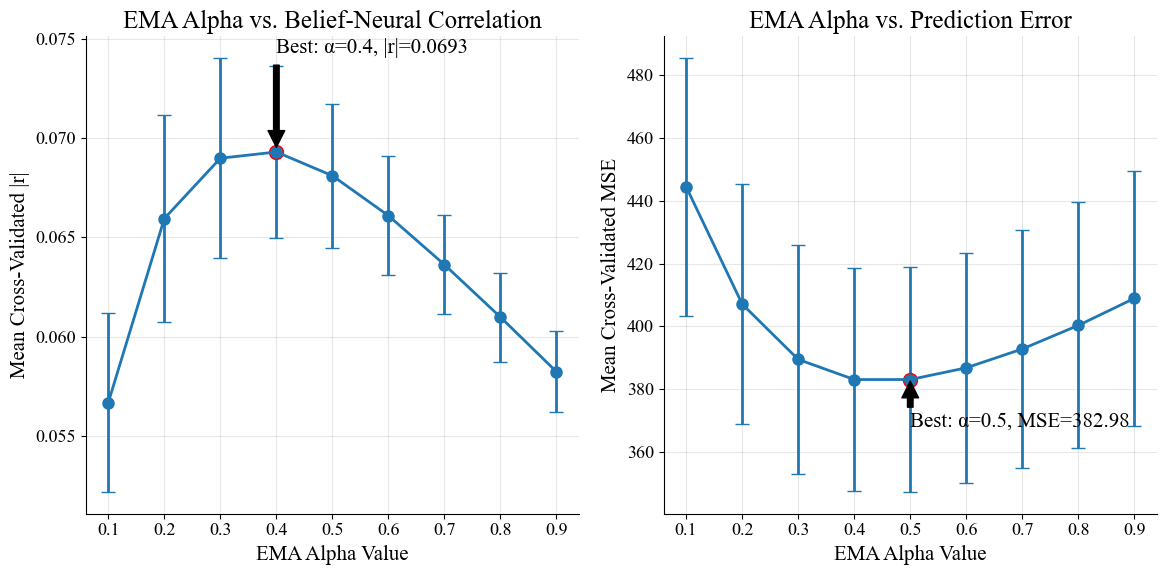


=== Results Summary (Sorted by Correlation) ===
1. Alpha = 0.4: |r| = 0.069298, MSE = 382.985170
2. Alpha = 0.3: |r| = 0.068984, MSE = 389.403284
3. Alpha = 0.5: |r| = 0.068103, MSE = 382.981677
4. Alpha = 0.6: |r| = 0.066092, MSE = 386.723516
5. Alpha = 0.2: |r| = 0.065946, MSE = 407.050059
6. Alpha = 0.7: |r| = 0.063625, MSE = 392.743829
7. Alpha = 0.8: |r| = 0.060982, MSE = 400.261454
8. Alpha = 0.9: |r| = 0.058234, MSE = 408.880813
9. Alpha = 0.1: |r| = 0.056684, MSE = 444.464800


In [20]:
def analyze_ema_alpha_trend(timedf, sessdf, alpha_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_samples=5000, n_folds=5):
    """
    Analyze how different EMA alpha values affect the cross-validated correlation
    between neural activity and belief.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    alpha_values : list
        List of EMA alpha values to test
    n_samples : int
        Number of samples to use for analysis
    n_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Dictionary containing cross-validation results for different alpha values
    """
    # Extract belief data
    belief = np.array(timedf.belief)
    
    # Extract neural activity data
    neural_raw = np.vstack(timedf.PPC)
    n_neurons = neural_raw.shape[1]
    total_samples = len(belief)
    
    # Subsample if needed
    if n_samples < total_samples:
        np.random.seed(42)
        sample_indices = np.random.choice(total_samples, n_samples, replace=False)
        sample_indices.sort()  # Keep temporal order
        belief = belief[sample_indices]
        neural_raw = neural_raw[sample_indices]
        print(f"Using {n_samples} samples out of {total_samples} total samples")
    else:
        print(f"Using all {total_samples} samples")
    
    print(f"Testing {len(alpha_values)} EMA alpha values using {n_folds}-fold cross-validation")
    
    # Setup cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Store results for each alpha value
    results = {}
    
    for alpha in alpha_values:
        print(f"\nEvaluating EMA with alpha = {alpha}")
        
        # Process neural data with current alpha
        neural_ema = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neuron_data = neural_raw[:, i]
            ema_vals = [neuron_data[0]]  # Start with first value
            
            for j in range(1, len(neuron_data)):
                ema_val = alpha * neuron_data[j] + (1 - alpha) * ema_vals[-1]
                ema_vals.append(ema_val)
            
            neural_ema[:, i] = np.array(ema_vals)
        
        # Perform cross-validation
        cv_scores = []
        cv_corrs = []
        
        for train_idx, test_idx in kf.split(belief):
            # Split data
            X_train, X_test = neural_ema[train_idx], neural_ema[test_idx]
            y_train, y_test = belief[train_idx], belief[test_idx]
            
            # Train model on each neuron and get correlations
            neuron_test_corrs = []
            
            for i in range(n_neurons):
                # Create and train model
                model = LinearRegression()
                model.fit(X_train[:, i].reshape(-1, 1), y_train)
                
                # Make predictions
                neuron_pred = model.predict(X_test[:, i].reshape(-1, 1))
                
                # Calculate correlation on test set
                test_corr, _ = pearsonr(y_test, neuron_pred)
                neuron_test_corrs.append(abs(test_corr))  # Use absolute correlation
            
            # Calculate mean absolute correlation
            mean_abs_corr = np.mean(neuron_test_corrs)
            cv_corrs.append(mean_abs_corr)
            
            # Use all neurons together to predict belief
            multi_model = LinearRegression()
            multi_model.fit(X_train, y_train)
            
            # Calculate MSE
            y_pred = multi_model.predict(X_test)
            mse = np.mean((y_test - y_pred) ** 2)
            cv_scores.append(mse)
        
        # Store results
        results[alpha] = {
            'mean_cv_mse': np.mean(cv_scores),
            'std_cv_mse': np.std(cv_scores),
            'mean_cv_corr': np.mean(cv_corrs),
            'std_cv_corr': np.std(cv_corrs)
        }
        
        print(f"  Mean CV MSE: {results[alpha]['mean_cv_mse']:.6f} ± {results[alpha]['std_cv_mse']:.6f}")
        print(f"  Mean CV |r|: {results[alpha]['mean_cv_corr']:.6f} ± {results[alpha]['std_cv_corr']:.6f}")
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Plot correlation trend
    ax1 = plt.subplot(1, 2, 1)
    alphas = sorted(results.keys())
    corrs = [results[alpha]['mean_cv_corr'] for alpha in alphas]
    corr_stds = [results[alpha]['std_cv_corr'] for alpha in alphas]
    
    ax1.errorbar(alphas, corrs, yerr=corr_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax1.set_xlabel('EMA Alpha Value')
    ax1.set_ylabel('Mean Cross-Validated |r|')
    ax1.set_title('EMA Alpha vs. Belief-Neural Correlation')
    ax1.grid(True, alpha=0.3)
    
    # Add points for best values
    max_corr_idx = np.argmax(corrs)
    max_corr_alpha = alphas[max_corr_idx]
    max_corr = corrs[max_corr_idx]
    ax1.plot(max_corr_alpha, max_corr, 'o', color='red', markersize=10)
    ax1.annotate(f'Best: α={max_corr_alpha}, |r|={max_corr:.4f}', 
                xy=(max_corr_alpha, max_corr), 
                xytext=(max_corr_alpha, max_corr+0.005),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Plot MSE trend
    ax2 = plt.subplot(1, 2, 2)
    mses = [results[alpha]['mean_cv_mse'] for alpha in alphas]
    mse_stds = [results[alpha]['std_cv_mse'] for alpha in alphas]
    
    ax2.errorbar(alphas, mses, yerr=mse_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax2.set_xlabel('EMA Alpha Value')
    ax2.set_ylabel('Mean Cross-Validated MSE')
    ax2.set_title('EMA Alpha vs. Prediction Error')
    ax2.grid(True, alpha=0.3)
    
    # Add points for best values
    min_mse_idx = np.argmin(mses)
    min_mse_alpha = alphas[min_mse_idx]
    min_mse = mses[min_mse_idx]
    ax2.plot(min_mse_alpha, min_mse, 'o', color='red', markersize=10)
    ax2.annotate(f'Best: α={min_mse_alpha}, MSE={min_mse:.2f}', 
                xy=(min_mse_alpha, min_mse), 
                xytext=(min_mse_alpha, min_mse-15),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary in sorted order
    print("\n=== Results Summary (Sorted by Correlation) ===")
    sorted_alphas = sorted(results.items(), key=lambda x: x[1]['mean_cv_corr'], reverse=True)
    for i, (alpha, result) in enumerate(sorted_alphas):
        print(f"{i+1}. Alpha = {alpha}: |r| = {result['mean_cv_corr']:.6f}, MSE = {result['mean_cv_mse']:.6f}")
    
    return results, alphas, corrs, mses

# Call the function
results, alphas, corrs, mses = analyze_ema_alpha_trend(timedf, sessdf)

Using 5000 samples of 400117

Testing 9 alphas with 5‑fold CV
 α=0.1  LL = -17636332993.1 ± 3440259827.6   |r| = 0.1628 ± 0.0543
 α=0.2  LL = -18729145065.5 ± 5387710249.4   |r| = 0.2866 ± 0.0337
 α=0.3  LL = -19092605185.6 ± 6281120643.2   |r| = 0.3525 ± 0.0211
 α=0.4  LL = -19444207974.4 ± 6434220589.9   |r| = 0.3948 ± 0.0156
 α=0.5  LL = -19904136779.2 ± 6291025020.9   |r| = 0.4153 ± 0.0142
 α=0.6  LL = -20494216746.9 ± 6130335503.0   |r| = 0.4196 ± 0.0155
 α=0.7  LL = -21160538685.5 ± 6069447361.2   |r| = 0.4134 ± 0.0173
 α=0.8  LL = -21874396193.1 ± 6119690139.3   |r| = 0.4004 ± 0.0186
 α=0.9  LL = -22653741805.1 ± 6271620701.3   |r| = 0.3832 ± 0.0187


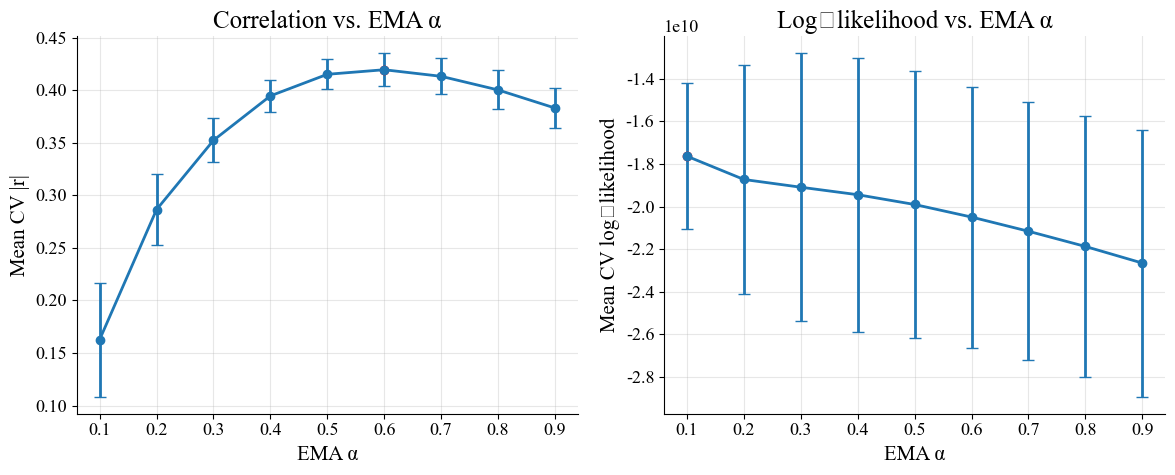


=== Sorted by log‑likelihood ===
 1. α=0.1  LL=-17636332993.1  |r|=0.1628
 2. α=0.2  LL=-18729145065.5  |r|=0.2866
 3. α=0.3  LL=-19092605185.6  |r|=0.3525
 4. α=0.4  LL=-19444207974.4  |r|=0.3948
 5. α=0.5  LL=-19904136779.2  |r|=0.4153
 6. α=0.6  LL=-20494216746.9  |r|=0.4196
 7. α=0.7  LL=-21160538685.5  |r|=0.4134
 8. α=0.8  LL=-21874396193.1  |r|=0.4004
 9. α=0.9  LL=-22653741805.1  |r|=0.3832


({0.1: {'mean_cv_ll': -17636332993.103477,
   'std_cv_ll': 3440259827.6054745,
   'mean_cv_corr': 0.16280918451947896,
   'std_cv_corr': 0.05427255342113732},
  0.2: {'mean_cv_ll': -18729145065.521248,
   'std_cv_ll': 5387710249.407867,
   'mean_cv_corr': 0.2865619038577883,
   'std_cv_corr': 0.03370343381934545},
  0.3: {'mean_cv_ll': -19092605185.600002,
   'std_cv_ll': 6281120643.174499,
   'mean_cv_corr': 0.35245887957431987,
   'std_cv_corr': 0.0211117013048711},
  0.4: {'mean_cv_ll': -19444207974.442467,
   'std_cv_ll': 6434220589.935149,
   'mean_cv_corr': 0.39475565619913916,
   'std_cv_corr': 0.015562520049191631},
  0.5: {'mean_cv_ll': -19904136779.153954,
   'std_cv_ll': 6291025020.934264,
   'mean_cv_corr': 0.4152952329020631,
   'std_cv_corr': 0.01424708498517771},
  0.6: {'mean_cv_ll': -20494216746.861504,
   'std_cv_ll': 6130335503.036827,
   'mean_cv_corr': 0.41964010855350314,
   'std_cv_corr': 0.015464107983276128},
  0.7: {'mean_cv_ll': -21160538685.462513,
   'std_c

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

def analyze_ema_alpha_trend_mle(
        timedf,
        sessdf=None,                     # kept for API compatibility
        alpha_values = (0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),
        n_samples    = 5_000,
        n_folds      = 5):
    """
    Test different EMA alphas by maximising the likelihood of y|x with known,
    observation‑specific variance.

    The noise variance for sample i is  timedf['uncertainty'][i][0,0].

    Returns
    -------
    results : dict, keyed by alpha, with mean / std of log‑likelihood and |r|.
    alphas, corrs, lls : convenience vectors for plotting.
    """

    # ----------  pull arrays ----------
    belief      = timedf["belief"].to_numpy()
    neural_raw  = np.vstack(timedf["PPC"])
    unc_var     = timedf["uncertainty"].apply(lambda m: m[0,0]).to_numpy()
    n_neurons   = neural_raw.shape[1]
    total_T     = belief.size

    # ----------  subsample, keeping temporal order ----------
    if n_samples < total_T:
        rng = np.random.default_rng(42)
        idx = np.sort(rng.choice(total_T, n_samples, replace=False))
        belief, neural_raw, unc_var = belief[idx], neural_raw[idx], unc_var[idx]
        print(f"Using {n_samples} samples of {total_T}")
    else:
        print(f"Using all {total_T} samples")

    # ----------  set up CV ----------
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {}

    print(f"\nTesting {len(alpha_values)} alphas with {n_folds}‑fold CV")
    for alpha in alpha_values:
        # ----- smooth each neuron with EMA(alpha) -----
        neural_ema = np.empty_like(neural_raw, dtype=float)
        for j in range(n_neurons):
            x = neural_raw[:, j]
            ema = np.empty_like(x, dtype=float)
            ema[0] = x[0]
            for t in range(1, len(x)):
                ema[t] = alpha * x[t] + (1 - alpha) * ema[t-1]
            neural_ema[:, j] = ema

        fold_ll, fold_corr = [], []

        for train_idx, test_idx in kf.split(belief):
            # split
            Xtr, Xte = neural_ema[train_idx], neural_ema[test_idx]
            ytr, yte = belief[train_idx], belief[test_idx]
            var_tr   = unc_var[train_idx]
            var_te   = unc_var[test_idx]

            # ----------  weighted least‑squares  ----------
            # sample weights = 1 / σ²_i  (MLE under heteroscedastic N(0,σ²_i))
            w = 1.0 / var_tr
            mdl = LinearRegression()
            mdl.fit(Xtr, ytr, sample_weight=w)

            # predict
            yhat = mdl.predict(Xte)

            # log‑likelihood on test fold
            ll = -0.5 * np.sum(
                    np.log(2*np.pi*var_te) +
                    ( (yte - yhat)**2 ) / var_te )
            fold_ll.append(ll)

            # correlation for interpretability
            r, _ = pearsonr(yte, yhat)
            fold_corr.append(abs(r))

        results[alpha] = dict(
            mean_cv_ll   = np.mean(fold_ll),
            std_cv_ll    = np.std(fold_ll),
            mean_cv_corr = np.mean(fold_corr),
            std_cv_corr  = np.std(fold_corr)
        )

        print(f" α={alpha:3.1f}  "
              f"LL = {results[alpha]['mean_cv_ll']:9.1f} ± {results[alpha]['std_cv_ll']:6.1f}   "
              f"|r| = {results[alpha]['mean_cv_corr']:.4f} ± {results[alpha]['std_cv_corr']:.4f}")

    # ----------  plotting ----------
    alphas = sorted(results)
    corrs  = [results[a]['mean_cv_corr'] for a in alphas]
    lls    = [results[a]['mean_cv_ll']   for a in alphas]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    # |r|
    ax1.errorbar(alphas, corrs,
                 yerr=[results[a]['std_cv_corr'] for a in alphas],
                 fmt="o-", capsize=4)
    ax1.set(xlabel="EMA α", ylabel="Mean CV |r|",
            title="Correlation vs. EMA α")
    ax1.grid(alpha=.3)
    best_r_idx = int(np.argmax(corrs))
    ax1.plot(alphas[best_r_idx], corrs[best_r_idx], "ro")

    # log‑likelihood
    ax2.errorbar(alphas, lls,
                 yerr=[results[a]['std_cv_ll'] for a in alphas],
                 fmt="o-", capsize=4)
    ax2.set(xlabel="EMA α", ylabel="Mean CV log‑likelihood",
            title="Log‑likelihood vs. EMA α")
    ax2.grid(alpha=.3)
    best_ll_idx = int(np.argmax(lls))
    ax2.plot(alphas[best_ll_idx], lls[best_ll_idx], "ro")

    plt.tight_layout(); plt.show()

    # ----------  tidy summary ----------
    print("\n=== Sorted by log‑likelihood ===")
    for i, (a, d) in enumerate(sorted(results.items(),
                                      key=lambda x: x[1]['mean_cv_ll'],
                                      reverse=True), 1):
        print(f"{i:2d}. α={a:3.1f}  "
              f"LL={d['mean_cv_ll']:9.1f}  |r|={d['mean_cv_corr']:.4f}")

    return results, alphas, corrs, lls
analyze_ema_alpha_trend_mle(
        timedf,
        sessdf=None,                     # kept for API compatibility
        alpha_values = (0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),
        n_samples    = 5_000,
        n_folds      = 5)

In [16]:
timedf.columns

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

Using 5000 samples out of 400117 total samples
Testing 9 EMA alpha values using 5-fold cross-validation

Evaluating EMA with alpha = 0.1
  Mean CV MSE: 300.605469 ± 8.918179
  Mean CV |r|: 0.052960 ± 0.002838

Evaluating EMA with alpha = 0.2
  Mean CV MSE: 274.769287 ± 6.739664
  Mean CV |r|: 0.062862 ± 0.003014

Evaluating EMA with alpha = 0.3
  Mean CV MSE: 258.369751 ± 5.474004
  Mean CV |r|: 0.068417 ± 0.003545

Evaluating EMA with alpha = 0.4
  Mean CV MSE: 248.555206 ± 5.056966
  Mean CV |r|: 0.071154 ± 0.003683

Evaluating EMA with alpha = 0.5
  Mean CV MSE: 243.321487 ± 5.487679
  Mean CV |r|: 0.072225 ± 0.003696

Evaluating EMA with alpha = 0.6
  Mean CV MSE: 241.330643 ± 6.381333
  Mean CV |r|: 0.072090 ± 0.003651

Evaluating EMA with alpha = 0.7
  Mean CV MSE: 241.731369 ± 7.419058
  Mean CV |r|: 0.071147 ± 0.003556

Evaluating EMA with alpha = 0.8
  Mean CV MSE: 244.002594 ± 8.448704
  Mean CV |r|: 0.069571 ± 0.003464

Evaluating EMA with alpha = 0.9
  Mean CV MSE: 247.8286

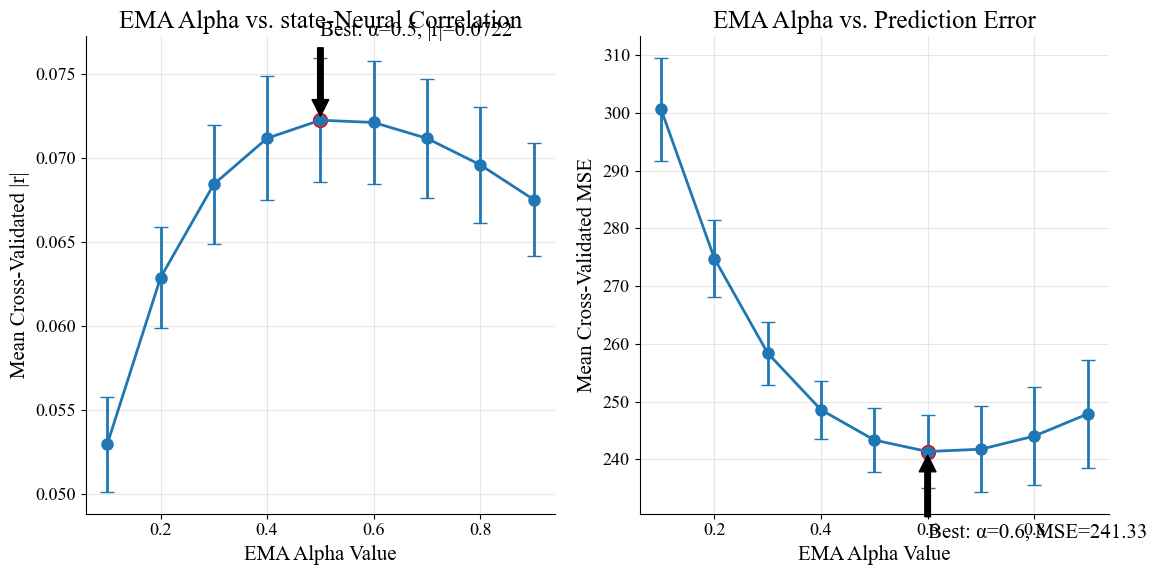


=== Results Summary (Sorted by Correlation) ===
1. Alpha = 0.5: |r| = 0.072225, MSE = 243.321487
2. Alpha = 0.6: |r| = 0.072090, MSE = 241.330643
3. Alpha = 0.4: |r| = 0.071154, MSE = 248.555206
4. Alpha = 0.7: |r| = 0.071147, MSE = 241.731369
5. Alpha = 0.8: |r| = 0.069571, MSE = 244.002594
6. Alpha = 0.3: |r| = 0.068417, MSE = 258.369751
7. Alpha = 0.9: |r| = 0.067510, MSE = 247.828659
8. Alpha = 0.2: |r| = 0.062862, MSE = 274.769287
9. Alpha = 0.1: |r| = 0.052960, MSE = 300.605469


In [21]:
def analyze_ema_alpha_trend(timedf, sessdf, alpha_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_samples=5000, n_folds=5):
    """
    Analyze how different EMA alpha values affect the cross-validated correlation
    between neural activity and state.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    alpha_values : list
        List of EMA alpha values to test
    n_samples : int
        Number of samples to use for analysis
    n_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Dictionary containing cross-validation results for different alpha values
    """
    # Extract state data
    state = np.array(timedf.state)
    
    # Extract neural activity data
    neural_raw = np.vstack(timedf.PPC)
    n_neurons = neural_raw.shape[1]
    total_samples = len(state)
    
    # Subsample if needed
    if n_samples < total_samples:
        np.random.seed(42)
        sample_indices = np.random.choice(total_samples, n_samples, replace=False)
        sample_indices.sort()  # Keep temporal order
        state = state[sample_indices]
        neural_raw = neural_raw[sample_indices]
        print(f"Using {n_samples} samples out of {total_samples} total samples")
    else:
        print(f"Using all {total_samples} samples")
    
    print(f"Testing {len(alpha_values)} EMA alpha values using {n_folds}-fold cross-validation")
    
    # Setup cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Store results for each alpha value
    results = {}
    
    for alpha in alpha_values:
        print(f"\nEvaluating EMA with alpha = {alpha}")
        
        # Process neural data with current alpha
        neural_ema = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neuron_data = neural_raw[:, i]
            ema_vals = [neuron_data[0]]  # Start with first value
            
            for j in range(1, len(neuron_data)):
                ema_val = alpha * neuron_data[j] + (1 - alpha) * ema_vals[-1]
                ema_vals.append(ema_val)
            
            neural_ema[:, i] = np.array(ema_vals)
        
        # Perform cross-validation
        cv_scores = []
        cv_corrs = []
        
        for train_idx, test_idx in kf.split(state):
            # Split data
            X_train, X_test = neural_ema[train_idx], neural_ema[test_idx]
            y_train, y_test = state[train_idx], state[test_idx]
            
            # Train model on each neuron and get correlations
            neuron_test_corrs = []
            
            for i in range(n_neurons):
                # Create and train model
                model = LinearRegression()
                model.fit(X_train[:, i].reshape(-1, 1), y_train)
                
                # Make predictions
                neuron_pred = model.predict(X_test[:, i].reshape(-1, 1))
                
                # Calculate correlation on test set
                test_corr, _ = pearsonr(y_test, neuron_pred)
                neuron_test_corrs.append(abs(test_corr))  # Use absolute correlation
            
            # Calculate mean absolute correlation
            mean_abs_corr = np.mean(neuron_test_corrs)
            cv_corrs.append(mean_abs_corr)
            
            # Use all neurons together to predict state
            multi_model = LinearRegression()
            multi_model.fit(X_train, y_train)
            
            # Calculate MSE
            y_pred = multi_model.predict(X_test)
            mse = np.mean((y_test - y_pred) ** 2)
            cv_scores.append(mse)
        
        # Store results
        results[alpha] = {
            'mean_cv_mse': np.mean(cv_scores),
            'std_cv_mse': np.std(cv_scores),
            'mean_cv_corr': np.mean(cv_corrs),
            'std_cv_corr': np.std(cv_corrs)
        }
        
        print(f"  Mean CV MSE: {results[alpha]['mean_cv_mse']:.6f} ± {results[alpha]['std_cv_mse']:.6f}")
        print(f"  Mean CV |r|: {results[alpha]['mean_cv_corr']:.6f} ± {results[alpha]['std_cv_corr']:.6f}")
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Plot correlation trend
    ax1 = plt.subplot(1, 2, 1)
    alphas = sorted(results.keys())
    corrs = [results[alpha]['mean_cv_corr'] for alpha in alphas]
    corr_stds = [results[alpha]['std_cv_corr'] for alpha in alphas]
    
    ax1.errorbar(alphas, corrs, yerr=corr_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax1.set_xlabel('EMA Alpha Value')
    ax1.set_ylabel('Mean Cross-Validated |r|')
    ax1.set_title('EMA Alpha vs. state-Neural Correlation')
    ax1.grid(True, alpha=0.3)
    
    # Add points for best values
    max_corr_idx = np.argmax(corrs)
    max_corr_alpha = alphas[max_corr_idx]
    max_corr = corrs[max_corr_idx]
    ax1.plot(max_corr_alpha, max_corr, 'o', color='red', markersize=10)
    ax1.annotate(f'Best: α={max_corr_alpha}, |r|={max_corr:.4f}', 
                xy=(max_corr_alpha, max_corr), 
                xytext=(max_corr_alpha, max_corr+0.005),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Plot MSE trend
    ax2 = plt.subplot(1, 2, 2)
    mses = [results[alpha]['mean_cv_mse'] for alpha in alphas]
    mse_stds = [results[alpha]['std_cv_mse'] for alpha in alphas]
    
    ax2.errorbar(alphas, mses, yerr=mse_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax2.set_xlabel('EMA Alpha Value')
    ax2.set_ylabel('Mean Cross-Validated MSE')
    ax2.set_title('EMA Alpha vs. Prediction Error')
    ax2.grid(True, alpha=0.3)
    
    # Add points for best values
    min_mse_idx = np.argmin(mses)
    min_mse_alpha = alphas[min_mse_idx]
    min_mse = mses[min_mse_idx]
    ax2.plot(min_mse_alpha, min_mse, 'o', color='red', markersize=10)
    ax2.annotate(f'Best: α={min_mse_alpha}, MSE={min_mse:.2f}', 
                xy=(min_mse_alpha, min_mse), 
                xytext=(min_mse_alpha, min_mse-15),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary in sorted order
    print("\n=== Results Summary (Sorted by Correlation) ===")
    sorted_alphas = sorted(results.items(), key=lambda x: x[1]['mean_cv_corr'], reverse=True)
    for i, (alpha, result) in enumerate(sorted_alphas):
        print(f"{i+1}. Alpha = {alpha}: |r| = {result['mean_cv_corr']:.6f}, MSE = {result['mean_cv_mse']:.6f}")
    
    return results, alphas, corrs, mses

# Call the function
results, alphas, corrs, mses = analyze_ema_alpha_trend(timedf, sessdf)

Using 5000 samples out of 400117 total samples
Testing 9 EMA alpha values using 5-fold cross-validation

Evaluating EMA with alpha = 0.1
  Mean CV MSE: 58.235645 ± 1.240960
  Mean CV |r|: 0.060030 ± 0.004340

Evaluating EMA with alpha = 0.2
  Mean CV MSE: 51.174068 ± 1.067803
  Mean CV |r|: 0.068650 ± 0.004113

Evaluating EMA with alpha = 0.3
  Mean CV MSE: 46.952984 ± 1.141524
  Mean CV |r|: 0.072209 ± 0.003828

Evaluating EMA with alpha = 0.4
  Mean CV MSE: 44.432476 ± 1.334764
  Mean CV |r|: 0.073244 ± 0.003630

Evaluating EMA with alpha = 0.5
  Mean CV MSE: 43.101929 ± 1.485248
  Mean CV |r|: 0.072656 ± 0.003457

Evaluating EMA with alpha = 0.6
  Mean CV MSE: 42.658012 ± 1.582080
  Mean CV |r|: 0.071064 ± 0.003326

Evaluating EMA with alpha = 0.7
  Mean CV MSE: 42.896538 ± 1.644832
  Mean CV |r|: 0.068720 ± 0.003206

Evaluating EMA with alpha = 0.8
  Mean CV MSE: 43.673470 ± 1.688071
  Mean CV |r|: 0.066028 ± 0.003082

Evaluating EMA with alpha = 0.9
  Mean CV MSE: 44.885002 ± 1.71

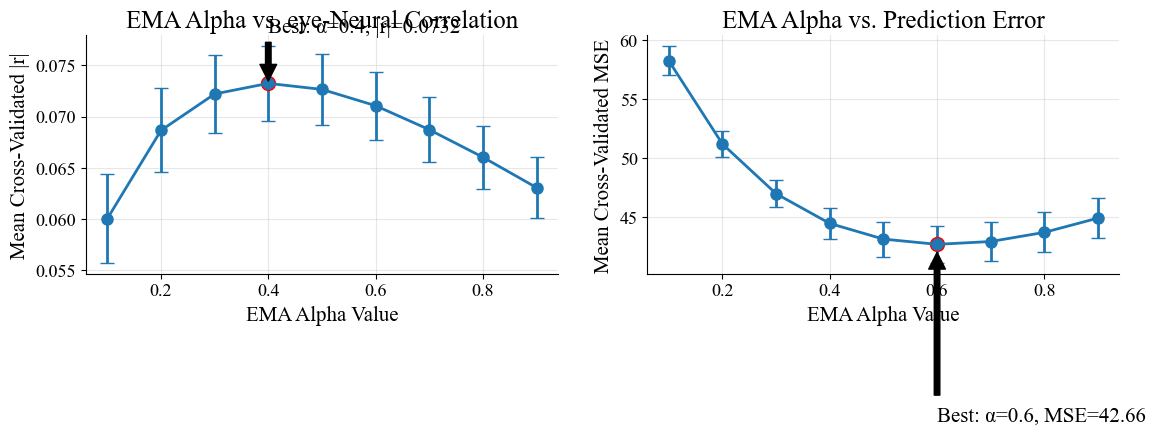


=== Results Summary (Sorted by Correlation) ===
1. Alpha = 0.4: |r| = 0.073244, MSE = 44.432476
2. Alpha = 0.5: |r| = 0.072656, MSE = 43.101929
3. Alpha = 0.3: |r| = 0.072209, MSE = 46.952984
4. Alpha = 0.6: |r| = 0.071064, MSE = 42.658012
5. Alpha = 0.7: |r| = 0.068720, MSE = 42.896538
6. Alpha = 0.2: |r| = 0.068650, MSE = 51.174068
7. Alpha = 0.8: |r| = 0.066028, MSE = 43.673470
8. Alpha = 0.9: |r| = 0.063056, MSE = 44.885002
9. Alpha = 0.1: |r| = 0.060030, MSE = 58.235645


In [28]:
def analyze_ema_alpha_trend(timedf, sessdf, alpha_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_samples=5000, n_folds=5):
    """
    Analyze how different EMA alpha values affect the cross-validated correlation
    between neural activity and eye.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    alpha_values : list
        List of EMA alpha values to test
    n_samples : int
        Number of samples to use for analysis
    n_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Dictionary containing cross-validation results for different alpha values
    """
    # Extract eye data
    eye = np.array(timedf.eye)
    
    # Extract neural activity data
    neural_raw = np.vstack(timedf.PPC)
    n_neurons = neural_raw.shape[1]
    total_samples = len(eye)
    
    # Subsample if needed
    if n_samples < total_samples:
        np.random.seed(42)
        sample_indices = np.random.choice(total_samples, n_samples, replace=False)
        sample_indices.sort()  # Keep temporal order
        eye = eye[sample_indices]
        neural_raw = neural_raw[sample_indices]
        print(f"Using {n_samples} samples out of {total_samples} total samples")
    else:
        print(f"Using all {total_samples} samples")
    
    print(f"Testing {len(alpha_values)} EMA alpha values using {n_folds}-fold cross-validation")
    
    # Setup cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Store results for each alpha value
    results = {}
    
    for alpha in alpha_values:
        print(f"\nEvaluating EMA with alpha = {alpha}")
        
        # Process neural data with current alpha
        neural_ema = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neuron_data = neural_raw[:, i]
            ema_vals = [neuron_data[0]]  # Start with first value
            
            for j in range(1, len(neuron_data)):
                ema_val = alpha * neuron_data[j] + (1 - alpha) * ema_vals[-1]
                ema_vals.append(ema_val)
            
            neural_ema[:, i] = np.array(ema_vals)
        
        # Perform cross-validation
        cv_scores = []
        cv_corrs = []
        
        for train_idx, test_idx in kf.split(eye):
            # Split data
            X_train, X_test = neural_ema[train_idx], neural_ema[test_idx]
            y_train, y_test = eye[train_idx], eye[test_idx]
            
            # Train model on each neuron and get correlations
            neuron_test_corrs = []
            
            for i in range(n_neurons):
                # Create and train model
                model = LinearRegression()
                model.fit(X_train[:, i].reshape(-1, 1), y_train)
                
                # Make predictions
                neuron_pred = model.predict(X_test[:, i].reshape(-1, 1))
                
                # Calculate correlation on test set
                test_corr, _ = pearsonr(y_test, neuron_pred)
                neuron_test_corrs.append(abs(test_corr))  # Use absolute correlation
            
            # Calculate mean absolute correlation
            mean_abs_corr = np.mean(neuron_test_corrs)
            cv_corrs.append(mean_abs_corr)
            
            # Use all neurons together to predict eye
            multi_model = LinearRegression()
            multi_model.fit(X_train, y_train)
            
            # Calculate MSE
            y_pred = multi_model.predict(X_test)
            mse = np.mean((y_test - y_pred) ** 2)
            cv_scores.append(mse)
        
        # Store results
        results[alpha] = {
            'mean_cv_mse': np.mean(cv_scores),
            'std_cv_mse': np.std(cv_scores),
            'mean_cv_corr': np.mean(cv_corrs),
            'std_cv_corr': np.std(cv_corrs)
        }
        
        print(f"  Mean CV MSE: {results[alpha]['mean_cv_mse']:.6f} ± {results[alpha]['std_cv_mse']:.6f}")
        print(f"  Mean CV |r|: {results[alpha]['mean_cv_corr']:.6f} ± {results[alpha]['std_cv_corr']:.6f}")
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Plot correlation trend
    ax1 = plt.subplot(1, 2, 1)
    alphas = sorted(results.keys())
    corrs = [results[alpha]['mean_cv_corr'] for alpha in alphas]
    corr_stds = [results[alpha]['std_cv_corr'] for alpha in alphas]
    
    ax1.errorbar(alphas, corrs, yerr=corr_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax1.set_xlabel('EMA Alpha Value')
    ax1.set_ylabel('Mean Cross-Validated |r|')
    ax1.set_title('EMA Alpha vs. eye-Neural Correlation')
    ax1.grid(True, alpha=0.3)
    
    # Add points for best values
    max_corr_idx = np.argmax(corrs)
    max_corr_alpha = alphas[max_corr_idx]
    max_corr = corrs[max_corr_idx]
    ax1.plot(max_corr_alpha, max_corr, 'o', color='red', markersize=10)
    ax1.annotate(f'Best: α={max_corr_alpha}, |r|={max_corr:.4f}', 
                xy=(max_corr_alpha, max_corr), 
                xytext=(max_corr_alpha, max_corr+0.005),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Plot MSE trend
    ax2 = plt.subplot(1, 2, 2)
    mses = [results[alpha]['mean_cv_mse'] for alpha in alphas]
    mse_stds = [results[alpha]['std_cv_mse'] for alpha in alphas]
    
    ax2.errorbar(alphas, mses, yerr=mse_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax2.set_xlabel('EMA Alpha Value')
    ax2.set_ylabel('Mean Cross-Validated MSE')
    ax2.set_title('EMA Alpha vs. Prediction Error')
    ax2.grid(True, alpha=0.3)
    
    # Add points for best values
    min_mse_idx = np.argmin(mses)
    min_mse_alpha = alphas[min_mse_idx]
    min_mse = mses[min_mse_idx]
    ax2.plot(min_mse_alpha, min_mse, 'o', color='red', markersize=10)
    ax2.annotate(f'Best: α={min_mse_alpha}, MSE={min_mse:.2f}', 
                xy=(min_mse_alpha, min_mse), 
                xytext=(min_mse_alpha, min_mse-15),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary in sorted order
    print("\n=== Results Summary (Sorted by Correlation) ===")
    sorted_alphas = sorted(results.items(), key=lambda x: x[1]['mean_cv_corr'], reverse=True)
    for i, (alpha, result) in enumerate(sorted_alphas):
        print(f"{i+1}. Alpha = {alpha}: |r| = {result['mean_cv_corr']:.6f}, MSE = {result['mean_cv_mse']:.6f}")
    
    return results, alphas, corrs, mses

# Call the function
results, alphas, corrs, mses = analyze_ema_alpha_trend(timedf, sessdf)

Using 5000 samples of 400117

Testing 9 α values with 5‑fold CV
α=0.1  belief LL=-17636332993.1 |r|=0.163   state LL=  -7928.1 |r|=0.366
α=0.2  belief LL=-18729145065.5 |r|=0.287   state LL=  -7481.6 |r|=0.454
α=0.3  belief LL=-19092605185.6 |r|=0.352   state LL=  -7171.6 |r|=0.506
α=0.4  belief LL=-19444207974.4 |r|=0.395   state LL=  -6967.1 |r|=0.539
α=0.5  belief LL=-19904136779.2 |r|=0.415   state LL=  -6841.6 |r|=0.557
α=0.6  belief LL=-20494216746.9 |r|=0.420   state LL=  -6777.1 |r|=0.567
α=0.7  belief LL=-21160538685.5 |r|=0.413   state LL=  -6761.2 |r|=0.569
α=0.8  belief LL=-21874396193.1 |r|=0.400   state LL=  -6784.5 |r|=0.566
α=0.9  belief LL=-22653741805.1 |r|=0.383   state LL=  -6840.3 |r|=0.557


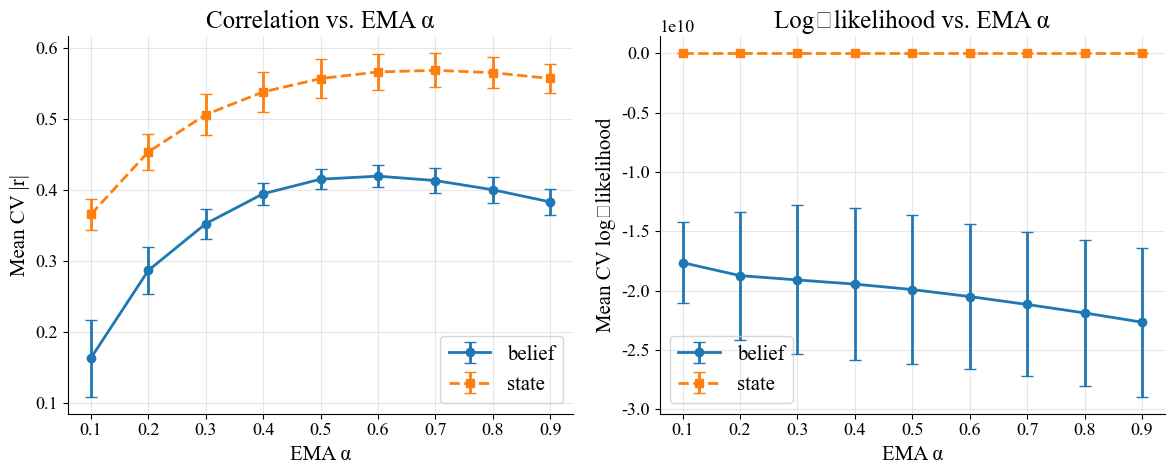

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

def analyze_alpha_belief_vs_state(
        timedf,
        state_col   = "state",          # column with ground‑truth latent state
        alpha_values= (0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),
        n_samples   = 5_000,
        n_folds     = 5):
    """
    EMA‑smooth neural data and compare population decoding of
      • belief  (heteroscedastic σ² from timedf['uncertainty'][:,0,0])
      • state   (homoscedastic σ² = global mean uncertainty)

    Returns two result dictionaries indexed by α.
    """

    # ----------  pull arrays ----------
    belief      = timedf["belief"].to_numpy()
    state       = timedf[state_col].to_numpy()
    neural_raw  = np.vstack(timedf["PPC"])
    unc_var     = timedf["uncertainty"].apply(lambda m: m[0,0]).to_numpy()
    mean_unc    = np.mean(unc_var)                    # for homoscedastic state fit
    n_neurons   = neural_raw.shape[1]
    total_T     = belief.size

    # ----------  subsample ----------
    if n_samples < total_T:
        rng  = np.random.default_rng(42)
        idx  = np.sort(rng.choice(total_T, n_samples, replace=False))
        belief, state = belief[idx], state[idx]
        neural_raw    = neural_raw[idx]
        unc_var       = unc_var[idx]
        print(f"Using {n_samples} samples of {total_T}")
    else:
        print(f"Using all {total_T} samples")

    kf        = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    res_bel   = {}
    res_state = {}

    print(f"\nTesting {len(alpha_values)} α values with {n_folds}‑fold CV")
    for α in alpha_values:
        # ----- EMA smooth -----
        neural_ema = np.empty_like(neural_raw, dtype=float)
        for j in range(n_neurons):
            x, ema = neural_raw[:, j], np.empty_like(neural_raw[:, j], float)
            ema[0] = x[0]
            for t in range(1, len(x)):
                ema[t] = α * x[t] + (1-α) * ema[t-1]
            neural_ema[:, j] = ema

        # containers
        bel_ll, bel_r = [], []
        sta_ll, sta_r = [], []

        for tr_idx, te_idx in kf.split(belief):
            Xtr, Xte = neural_ema[tr_idx], neural_ema[te_idx]

            # ----------  belief ----------
            ytr_b, yte_b = belief[tr_idx], belief[te_idx]
            var_tr, var_te = unc_var[tr_idx], unc_var[te_idx]

            mdl_b = LinearRegression().fit(Xtr, ytr_b, sample_weight=1/var_tr)
            pred_b = mdl_b.predict(Xte)

            bel_ll.append(
                -0.5 * np.sum(np.log(2*np.pi*var_te) + (yte_b-pred_b)**2 / var_te)
            )
            bel_r.append(abs(pearsonr(yte_b, pred_b)[0]))

            # ----------  state ----------
            ytr_s, yte_s = state[tr_idx], state[te_idx]

            mdl_s = LinearRegression().fit(Xtr, ytr_s)   # equal weights
            pred_s = mdl_s.predict(Xte)

            sta_ll.append(
                -0.5 * np.sum(np.log(2*np.pi*mean_unc) + (yte_s-pred_s)**2 / mean_unc)
            )
            sta_r.append(abs(pearsonr(yte_s, pred_s)[0]))

        res_bel[α]   = dict(mean_ll=np.mean(bel_ll),  std_ll=np.std(bel_ll),
                            mean_r =np.mean(bel_r),  std_r =np.std(bel_r))
        res_state[α] = dict(mean_ll=np.mean(sta_ll),  std_ll=np.std(sta_ll),
                            mean_r =np.mean(sta_r),  std_r =np.std(sta_r))

        print(f"α={α:3.1f}  belief LL={res_bel[α]['mean_ll']:9.1f} "
              f"|r|={res_bel[α]['mean_r']:.3f}   "
              f"state LL={res_state[α]['mean_ll']:9.1f} "
              f"|r|={res_state[α]['mean_r']:.3f}")

    # ----------  plotting ----------
    alphas      = sorted(res_bel)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

    # correlation panel
    ax1.errorbar(alphas, [res_bel[a]['mean_r'] for a in alphas],
                 yerr=[res_bel[a]['std_r']  for a in alphas],
                 fmt="o-", capsize=4, label="belief")
    ax1.errorbar(alphas, [res_state[a]['mean_r'] for a in alphas],
                 yerr=[res_state[a]['std_r'] for a in alphas],
                 fmt="s--", capsize=4, label="state")
    ax1.set(xlabel="EMA α", ylabel="Mean CV |r|",
            title="Correlation vs. EMA α"); ax1.grid(alpha=.3); ax1.legend()

    # log‑likelihood panel
    ax2.errorbar(alphas, [res_bel[a]['mean_ll'] for a in alphas],
                 yerr=[res_bel[a]['std_ll']  for a in alphas],
                 fmt="o-", capsize=4, label="belief")
    ax2.errorbar(alphas, [res_state[a]['mean_ll'] for a in alphas],
                 yerr=[res_state[a]['std_ll'] for a in alphas],
                 fmt="s--", capsize=4, label="state")
    ax2.set(xlabel="EMA α", ylabel="Mean CV log‑likelihood",
            title="Log‑likelihood vs. EMA α"); ax2.grid(alpha=.3); ax2.legend()

    plt.tight_layout(); plt.show()

    return res_bel, res_state


res_bel, res_state = analyze_alpha_belief_vs_state(timedf)




Using 5000 samples of 400117

Testing 9 α values with 5‑fold CV
α=0.1 | belief LL=-17636332993.1 |r|=0.163  state LL=  -7928.1 |r|=0.366  eye LL=  -3682.9 |r|=0.444
α=0.2 | belief LL=-18729145065.5 |r|=0.287  state LL=  -7481.6 |r|=0.454  eye LL=  -3557.0 |r|=0.540
α=0.3 | belief LL=-19092605185.6 |r|=0.352  state LL=  -7171.6 |r|=0.506  eye LL=  -3475.0 |r|=0.594
α=0.4 | belief LL=-19444207974.4 |r|=0.395  state LL=  -6967.1 |r|=0.539  eye LL=  -3423.0 |r|=0.626
α=0.5 | belief LL=-19904136779.2 |r|=0.415  state LL=  -6841.6 |r|=0.557  eye LL=  -3393.3 |r|=0.644
α=0.6 | belief LL=-20494216746.9 |r|=0.420  state LL=  -6777.1 |r|=0.567  eye LL=  -3380.5 |r|=0.651
α=0.7 | belief LL=-21160538685.5 |r|=0.413  state LL=  -6761.2 |r|=0.569  eye LL=  -3380.6 |r|=0.651
α=0.8 | belief LL=-21874396193.1 |r|=0.400  state LL=  -6784.5 |r|=0.566  eye LL=  -3391.1 |r|=0.645
α=0.9 | belief LL=-22653741805.1 |r|=0.383  state LL=  -6840.3 |r|=0.557  eye LL=  -3410.0 |r|=0.633


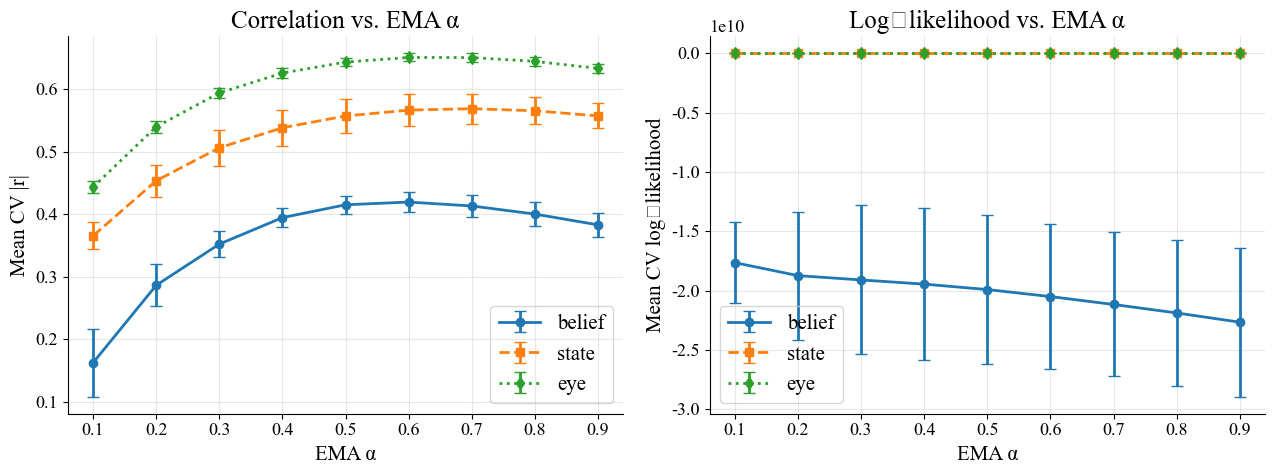

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

def analyze_alpha_decoding_three(
        timedf,
        state_col   = "state",
        eye_col     = "eye",
        alpha_values= (0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),
        n_samples   = 5_000,
        n_folds     = 5):
    """
    Compare EMA‑smoothed population decoding of belief (heteroscedastic),
    state (homoscedastic), and eye (homoscedastic).

    Returns three result dictionaries keyed by α.
    """

    # ---------- data ----------
    belief     = timedf["belief"].to_numpy()
    state      = timedf[state_col].to_numpy()
    eye        = timedf[eye_col].to_numpy()
    neural_raw = np.vstack(timedf["PPC"])
    unc_var    = timedf["uncertainty"].apply(lambda m: m[0,0]).to_numpy()
    mean_unc   = np.mean(unc_var)

    n_neurons, total_T = neural_raw.shape[1], belief.size

    # ---------- subsample ----------
    if n_samples < total_T:
        rng  = np.random.default_rng(42)
        idx  = np.sort(rng.choice(total_T, n_samples, replace=False))
        belief, state, eye = belief[idx], state[idx], eye[idx]
        neural_raw, unc_var = neural_raw[idx], unc_var[idx]
        print(f"Using {n_samples} samples of {total_T}")
    else:
        print(f"Using all {total_T} samples")

    kf          = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    res_bel, res_sta, res_eye = {}, {}, {}

    print(f"\nTesting {len(alpha_values)} α values with {n_folds}‑fold CV")
    for α in alpha_values:
        # ----- EMA smoothing -----
        neural_ema = np.empty_like(neural_raw, float)
        for j in range(n_neurons):
            x = neural_raw[:, j]
            ema = np.empty_like(x, float)
            ema[0] = x[0]
            for t in range(1, len(x)):
                ema[t] = α * x[t] + (1-α) * ema[t-1]
            neural_ema[:, j] = ema

        ll_b, r_b = [], []
        ll_s, r_s = [], []
        ll_e, r_e = [], []

        for tr, te in kf.split(belief):
            Xtr, Xte = neural_ema[tr], neural_ema[te]

            # belief (heteroscedastic)
            ytr_b, yte_b = belief[tr], belief[te]
            var_tr, var_te = unc_var[tr], unc_var[te]
            mdl_b = LinearRegression().fit(Xtr, ytr_b, sample_weight=1/var_tr)
            pred_b = mdl_b.predict(Xte)
            ll_b.append(-0.5*np.sum(np.log(2*np.pi*var_te)+(yte_b-pred_b)**2/var_te))
            r_b.append(abs(pearsonr(yte_b, pred_b)[0]))

            # state (homoscedastic mean_unc)
            ytr_s, yte_s = state[tr], state[te]
            mdl_s = LinearRegression().fit(Xtr, ytr_s)
            pred_s = mdl_s.predict(Xte)
            ll_s.append(-0.5*np.sum(np.log(2*np.pi*mean_unc)+(yte_s-pred_s)**2/mean_unc))
            r_s.append(abs(pearsonr(yte_s, pred_s)[0]))

            # eye   (homoscedastic mean_unc)
            ytr_e, yte_e = eye[tr], eye[te]
            mdl_e = LinearRegression().fit(Xtr, ytr_e)
            pred_e = mdl_e.predict(Xte)
            ll_e.append(-0.5*np.sum(np.log(2*np.pi*mean_unc)+(yte_e-pred_e)**2/mean_unc))
            r_e.append(abs(pearsonr(yte_e, pred_e)[0]))

        # store results
        res_bel[α] = dict(mean_ll=np.mean(ll_b), std_ll=np.std(ll_b),
                          mean_r=np.mean(r_b),  std_r=np.std(r_b))
        res_sta[α] = dict(mean_ll=np.mean(ll_s), std_ll=np.std(ll_s),
                          mean_r=np.mean(r_s),  std_r=np.std(r_s))
        res_eye[α] = dict(mean_ll=np.mean(ll_e), std_ll=np.std(ll_e),
                          mean_r=np.mean(r_e),  std_r=np.std(r_e))

        print(f"α={α:3.1f} | belief LL={res_bel[α]['mean_ll']:9.1f} "
              f"|r|={res_bel[α]['mean_r']:.3f}  "
              f"state LL={res_sta[α]['mean_ll']:9.1f} "
              f"|r|={res_sta[α]['mean_r']:.3f}  "
              f"eye LL={res_eye[α]['mean_ll']:9.1f} "
              f"|r|={res_eye[α]['mean_r']:.3f}")

    # ---------- plots ----------
    alphas = sorted(res_bel)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))

    def add_curve(ax, vals, errs, style, label):
        ax.errorbar(alphas, vals, yerr=errs, fmt=style, capsize=4, label=label)

    # correlation panel
    add_curve(ax1, [res_bel[a]['mean_r'] for a in alphas],
                   [res_bel[a]['std_r']  for a in alphas], "o-",  "belief")
    add_curve(ax1, [res_sta[a]['mean_r'] for a in alphas],
                   [res_sta[a]['std_r']  for a in alphas], "s--", "state")
    add_curve(ax1, [res_eye[a]['mean_r'] for a in alphas],
                   [res_eye[a]['std_r']  for a in alphas], "d:",  "eye")
    ax1.set(xlabel="EMA α", ylabel="Mean CV |r|",
            title="Correlation vs. EMA α"); ax1.grid(alpha=.3); ax1.legend()

    # log‑likelihood panel
    add_curve(ax2, [res_bel[a]['mean_ll'] for a in alphas],
                   [res_bel[a]['std_ll']  for a in alphas], "o-",  "belief")
    add_curve(ax2, [res_sta[a]['mean_ll'] for a in alphas],
                   [res_sta[a]['std_ll']  for a in alphas], "s--", "state")
    add_curve(ax2, [res_eye[a]['mean_ll'] for a in alphas],
                   [res_eye[a]['std_ll']  for a in alphas], "d:",  "eye")
    ax2.set(xlabel="EMA α", ylabel="Mean CV log‑likelihood",
            title="Log‑likelihood vs. EMA α"); ax2.grid(alpha=.3); ax2.legend()

    plt.tight_layout(); plt.show()
    return res_bel, res_sta, res_eye
res_bel, res_state, res_eye = analyze_alpha_decoding_three(timedf)
